In [1]:
from sklearn.datasets import fetch_openml

Boston = fetch_openml(name='boston',version=1, as_frame= True)
df=Boston.frame

In [2]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   CRIM     506 non-null    float64 
 1   ZN       506 non-null    float64 
 2   INDUS    506 non-null    float64 
 3   CHAS     506 non-null    category
 4   NOX      506 non-null    float64 
 5   RM       506 non-null    float64 
 6   AGE      506 non-null    float64 
 7   DIS      506 non-null    float64 
 8   RAD      506 non-null    category
 9   TAX      506 non-null    float64 
 10  PTRATIO  506 non-null    float64 
 11  B        506 non-null    float64 
 12  LSTAT    506 non-null    float64 
 13  MEDV     506 non-null    float64 
dtypes: category(2), float64(12)
memory usage: 49.0 KB


,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.554695,6.284634,68.574901,3.795043,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.115878,0.702617,28.148861,2.105710,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.385000,3.561000,2.900000,1.129600,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.449000,5.885500,45.025000,2.100175,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.538000,6.208500,77.500000,3.207450,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.624000,6.623500,94.075000,5.188425,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,0.871000,8.780000,100.000000,12.126500,711.000000,22.000000,396.900000,37.970000,50.000000


In [3]:
# Ask yourself what is the target variable over here the for house price prediction we are watching over price 
# here MEDV is the price for houses. 

print (df.columns)
print (df['MEDV'].describe())


Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='object')
count    506.000000
mean      22.532806
std        9.197104
min        5.000000
25%       17.025000
50%       21.200000
75%       25.000000
max       50.000000
Name: MEDV, dtype: float64


In [4]:
df.corr()['MEDV'].sort_values(ascending=False) # it give correlations.

C:\Users\16822\AppData\Local\Temp\ipykernel_1768\3006938660.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.corr()['MEDV'].sort_values(ascending=False) # it give correlations.


MEDV       1.000000
RM         0.695360
ZN         0.360445
B          0.333461
DIS        0.249929
AGE       -0.376955
CRIM      -0.388305
NOX       -0.427321
TAX       -0.468536
INDUS     -0.483725
PTRATIO   -0.507787
LSTAT     -0.737663
Name: MEDV, dtype: float64

RM (Average number of rooms) → strong positive correlation with price → makes sense, bigger homes = more value.

LSTAT (% lower status population) → strong negative correlation → also intuitive, higher poverty areas = lower prices.

PTRATIO (Pupil–teacher ratio) → moderate negative correlation → subtle but real; might indicate quality of education, affecting value.

<Axes: xlabel='MEDV', ylabel='Count'>

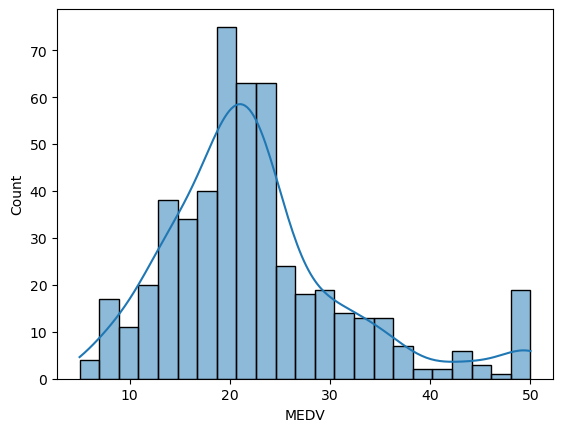

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns. histplot(df['MEDV'],kde=True) # histogram

🧪 Histogram of MEDV (Target)
✅ You said:

Distribution looks almost normal with 20-25K as the most frequent.

🔍 You're right — but there's a little twist:

MEDV is capped at 50.0 — it was a limit in the original dataset (they didn’t record values above it).

That makes the tail a bit right-skewed, and the model might misinterpret that cap as a real ceiling.

👉 Mental note: We might want to treat 50.0 values as potential outliers or special cases later.

<Axes: xlabel='RM', ylabel='MEDV'>

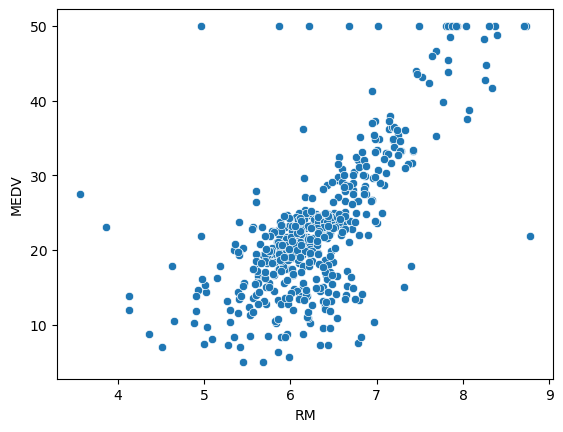

In [6]:
# pairplot / scatter plot 
sns.scatterplot(x="RM",y='MEDV',data=df)


<Axes: xlabel='LSTAT', ylabel='MEDV'>

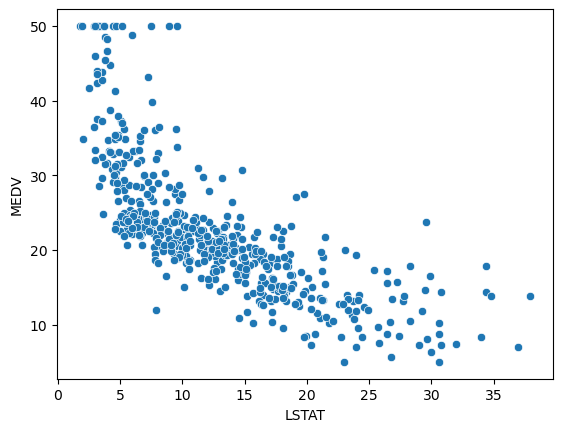

In [7]:
sns.scatterplot(x='LSTAT',y='MEDV',data=df)

📈 RM vs MEDV & LSTAT vs MEDV
✅ You nailed the interpretations:

RM → Linear and positive ✅

LSTAT → Linear and negative ✅

Outliers in RM → Yes, probably homes with 8+ rooms.

💡 Good catch: More rooms generally = higher price, but very large homes might behave differently (maybe they’re luxury or located in weird zones).


C:\Users\16822\AppData\Local\Temp\ipykernel_1768\429550690.py:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df.corr(),annot=True, cmap='coolwarm')


<Axes: >

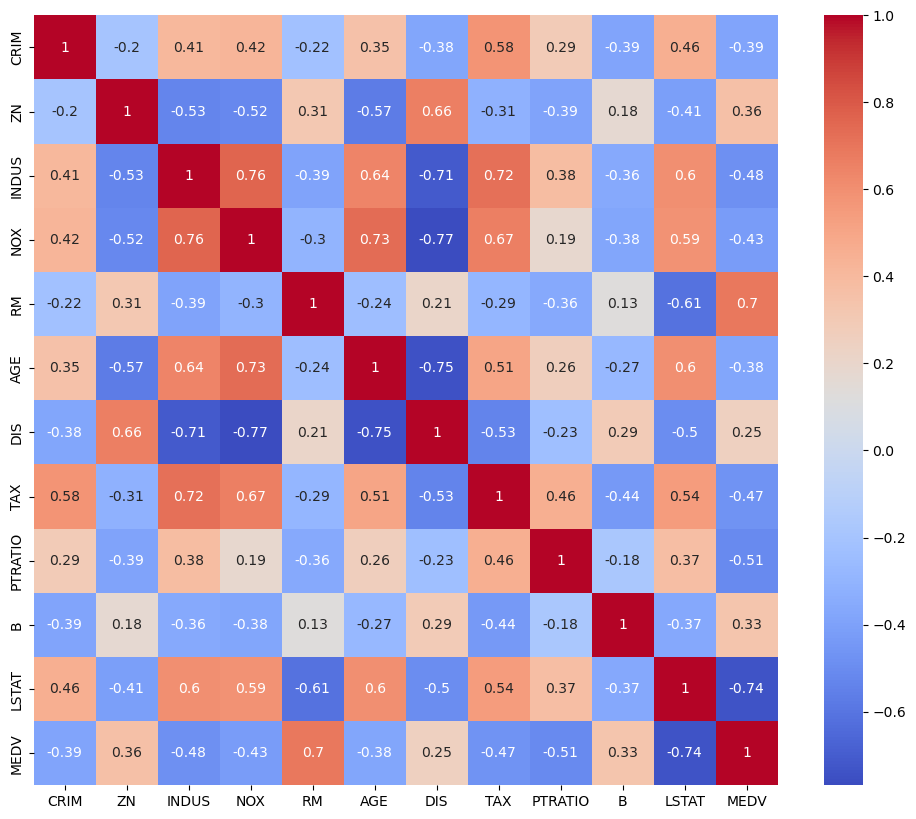

In [8]:
# Coorelation heat maps
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(),annot=True, cmap='coolwarm')

🧊 Heatmap & Correlation Matrix
You said:

Not sure how to judge this.

Let’s break it down:

Correlation values range from -1 to +1.

Closer to ±1 = stronger linear relationship.

Look for:

Very high correlations (e.g., > 0.7 or < -0.7)

Multicollinearity: features that are strongly correlated with each other, not just the target

🔥 For example:

TAX and RAD are often highly correlated → that could mess with some models (like linear regression).

So you're not missing anything, but here’s a tip:

Use correlation to detect redundancy (two features saying the same thing), or find important drivers of the target.



<Axes: xlabel='MEDV'>

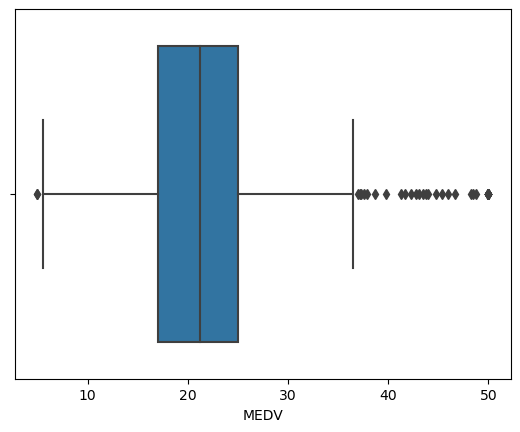

In [9]:
# BOX Plot
sns.boxplot(x=df['MEDV'])

📦 Boxplot of MEDV
✅ You saw:

Lots of outliers

🎯 Yes! Especially those exact 50.0 values — those aren’t random outliers, they're artificial caps.

Should you remove them?

Depends. If you keep them, your model might struggle near high price ranges.

If you remove them, you lose data but maybe improve generalization.

👉 We’ll test both approaches later. For now, just flag it.



❗ Outliers in RM:
Yes, but don't rush to delete them.

Try plotting a histogram of RM to decide:

python
Copy
Edit


<Axes: xlabel='RM', ylabel='Count'>

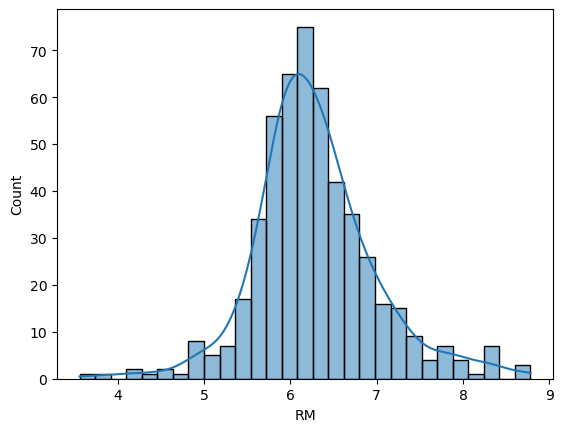

In [10]:
# RM histplot
sns.histplot(df['RM'], kde=True)

🛠 Options to Handle the MEDV == 50.0 Rows:
Drop them

✅ Simpler model

❌ Lose data (~15% of rows)

python
Copy
Edit
df = df[df["MEDV"] < 50.0]
Keep them

✅ Keep full dataset

❌ Your model might learn that "50" is a real max, not a cap

Label them separately (advanced)

Create a flag column like is_capped = (MEDV == 50.0)

You could even try modeling them differently (but skip this for now)

For now, I recommend:

🟨 Try training your model both with and without the capped values later and compare the effect.
For now, you can drop them temporarily to keep things clean. Cool?

🔁 Step 3: Preprocessing (Let’s go!)
✅ Goals:
Handle outliers or caps

Scale your features

Split into training/testing sets

In [11]:
df=df[df['MEDV']<50]

In [12]:
x=df.drop('MEDV',axis=1)
y=df['MEDV']


Feature Scaling 

In [13]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

X_scaled=scaler.fit_transform(x)

In [14]:
from sklearn .model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X_scaled,y,test_size=0.2,random_state=42)

🔍 Hints & Suggestions:
1. Start with Linear Regression

In [15]:
# Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error

model=LinearRegression()
model.fit(X_train,Y_train)

y_pred=model.predict(X_test)

mse=mean_squared_error(Y_test,y_pred)
mae=mean_absolute_error(Y_test,y_pred)

print(f'MSE:{mse},MAE:{mae}')

MSE:12.055902866387633,MAE:2.6415049059591578


🧮 MAE — Mean Absolute Error
The average of the absolute differences between predicted and actual values.

💡 Think of it like:

“On average, how many $1000s off am I per prediction?”

✅ Easy to interpret
✅ Less sensitive to outliers
❌ Treats all errors equally

📦 In your case:

text
Copy
Edit
MAE ≈ 2.64 → You’re off by ~$2,640 on average
🧮 MSE — Mean Squared Error
The average of squared differences between predicted and actual values.

💡 Think of it like:

“How bad are my errors, especially the big ones?”

✅ Punishes larger errors more heavily
❌ Not as interpretable in real-world units (because it's in squared terms)

📦 In your case:

text
Copy
Edit
MSE ≈ 12.06 → The squared error. 
(Root MSE = √12.06 ≈ 3.47 → on average, you're off by $3,470 but with more emphasis on bigger mistakes)
🥊 So… Which is Better?
Not one is better than the other — it depends:

Metric	Good For
MAE	When you want a clean average error in real units
MSE	When big errors matter more, like predicting medical doses, money, etc.
💡 Pro Tip:
You can calculate Root Mean Squared Error (RMSE) to bring MSE back to real-world units:

python
Copy
Edit
rmse = mse ** 0.5
print(f"RMSE: {rmse}")
Try that now, and then let’s discuss how good or bad these numbers are in your context. Then we’ll look at trying a better model next 👀

In [16]:
rmse = mse ** 0.5
print(f"RMSE: {rmse}")

RMSE: 3.472161123333368


You probably saw:

Mean ≈ 21.5 ($21,500)

Min ≈ 5.0, Max ≈ 50.0

So being off by ~2.6k–3.5k on an average 21.5k house = about 12–16% error. That's... decent, but not great.
🧠 Takeaway:
✅ Your linear model captured basic trends (like more rooms = higher price)
❌ But it struggles with more complex relationships, outliers, and non-linear patterns



# Lets use now no linear model as the linear models have low accuracy over here.
🚀 Step 4.5: Random Forest Regressor
🔍 Hints Before We Code:
🛠 Key hyperparameters to know (you’ll tune them later):
n_estimators: number of trees in the forest (default = 100, try more later)

max_depth: how deep each tree can go (prevents overfitting)

random_state: for reproducibility

max_features: how many features each tree sees (adds randomness)

In [20]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

rf_model= RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train,Y_train)

y_pred_rf=rf_model.predict(X_test)

mse_rf = mean_squared_error(Y_test, y_pred_rf)
mae_rf = mean_absolute_error(Y_test, y_pred_rf)
rmse_rf = mse_rf ** 0.5

print(f"Random Forest → MAE: {mae_rf:.2f}, RMSE: {rmse_rf:.2f}")

Random Forest → MAE: 1.80, RMSE: 2.42


This has much less error then the linear regression

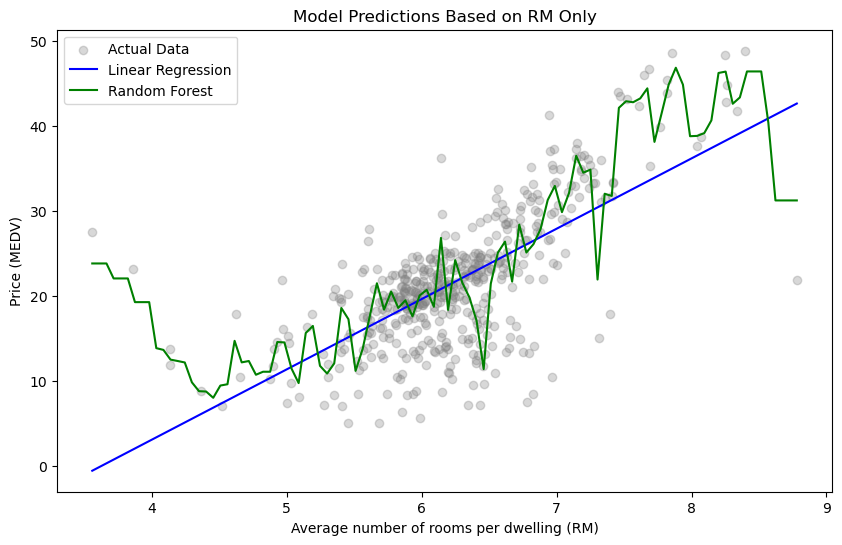

In [22]:
# Use the original, unscaled DataFrame (df)
import numpy as np
import matplotlib.pyplot as plt

# Select RM and MEDV
X_rm = df[["RM"]].values
y_medv = df["MEDV"].values

# Create range of RM values
rm_range = np.linspace(X_rm.min(), X_rm.max(), 100).reshape(-1, 1)

# Train both models on just RM (for visualization purposes)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

lin_vis = LinearRegression()
rf_vis = RandomForestRegressor(n_estimators=100, random_state=42)

lin_vis.fit(X_rm, y_medv)
rf_vis.fit(X_rm, y_medv)

# Predictions for that RM range
y_pred_lin = lin_vis.predict(rm_range)
y_pred_rf = rf_vis.predict(rm_range)

# Plotting
plt.figure(figsize=(10, 6))
plt.scatter(X_rm, y_medv, alpha=0.3, label="Actual Data", color="gray")
plt.plot(rm_range, y_pred_lin, label="Linear Regression", color="blue")
plt.plot(rm_range, y_pred_rf, label="Random Forest", color="green")
plt.xlabel("Average number of rooms per dwelling (RM)")
plt.ylabel("Price (MEDV)")
plt.title("Model Predictions Based on RM Only")
plt.legend()
plt.show()



“Hey, which features are you using the most to make decisions?”

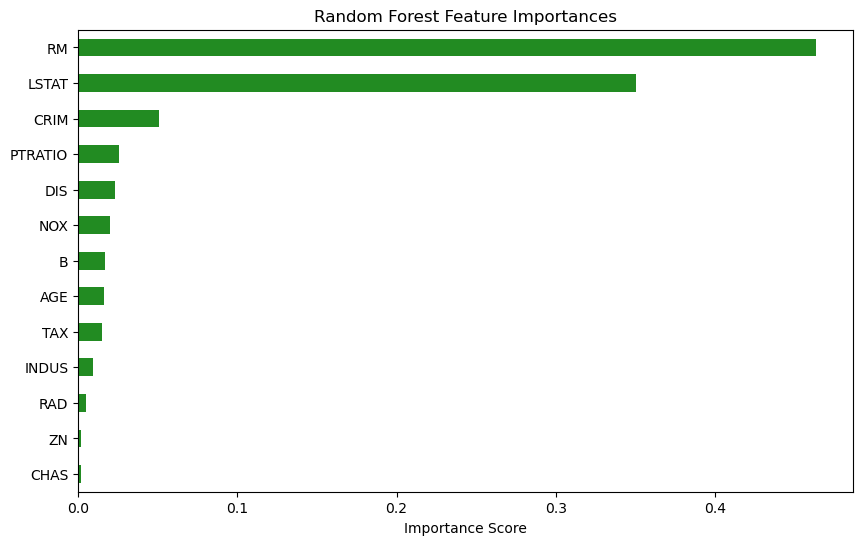

In [23]:
import pandas as pd

# Get feature importances from the trained random forest
importances = rf_model.feature_importances_

# Create a nice DataFrame
feat_importance = pd.Series(importances, index=df.columns.drop("MEDV"))
feat_importance = feat_importance.sort_values(ascending=True)

# Plot
plt.figure(figsize=(10, 6))
feat_importance.plot(kind="barh", color="forestgreen")
plt.title("Random Forest Feature Importances")
plt.xlabel("Importance Score")
plt.show()


🧠 Analogy Time:
Tuning a model is like cooking pasta:

Boil time, salt level, heat = hyperparameters

Pasta’s final texture = your model’s predictions

You tweak the knobs, the water boils differently



In [24]:
from sklearn.model_selection import GridSearchCV

# Define the hyperparameter options to try
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 20],
    'max_features': ['auto', 'sqrt'],
    'min_samples_split': [2, 5, 10]
}


from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(estimator=rf,
                           param_grid=param_grid,
                           cv=5,                # 5-fold cross validation
                           scoring='neg_mean_squared_error',
                           n_jobs=-1,           # use all CPU cores
                           verbose=2)


In [26]:
grid_search.fit(X_train, Y_train)


Fitting 5 folds for each of 72 candidates, totalling 360 fits


C:\Users\16822\AppData\Roaming\Python\Python310\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
180 fits failed out of a total of 360.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
125 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\16822\AppData\Roaming\Python\Python310\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\16822\AppData\Roaming\Python\Python310\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
  File "C:\Users\16822\AppData\Roaming\Python\Python310\site-packages\sklearn\base.py", line 436, in _validate_params
    vali

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 5, 10, 20],
                         'max_features': ['auto', 'sqrt'],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='neg_mean_squared_error', verbose=2)

In [27]:
print("Best Parameters:", grid_search.best_params_)
print("Best Score (MSE):", -grid_search.best_score_)



Best Parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 100}
Best Score (MSE): 8.365043536745748
